# 1) Imports and configuration

In [ ]:
# Basic libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Explainability libraries
# pip install shap
import shap
# pip install lime
import lime
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import PartialDependenceDisplay

# Imputation libraries
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import KNNImputer
from sklearn.impute import IterativeImputer
from missforest import MissForest

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Decision tree libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Multiclass classification
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import LinearSVC

# Counterfactual explanations
# pip install dice-ml
from PyALE import ale
import dice_ml

# Sampling techniques
# pip install imbalanced-learn
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Ignore all warnings
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


# 2) Loading

In [70]:
cirrhosis = pd.read_csv("datasets/cirrhosis.csv")

print(cirrhosis.shape)

(418, 20)


# 3) EDA

(418, 19)
['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Albumin', 'Platelets', 'Prothrombin', 'Stage', 'log_Bilirubin', 'log_Cholesterol', 'log_Copper', 'log_Alk_Phos', 'log_SGOT', 'log_Tryglicerides']


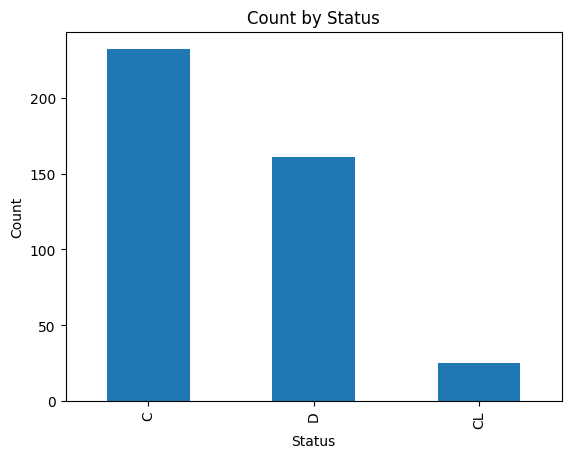

Status
Status patient distribution


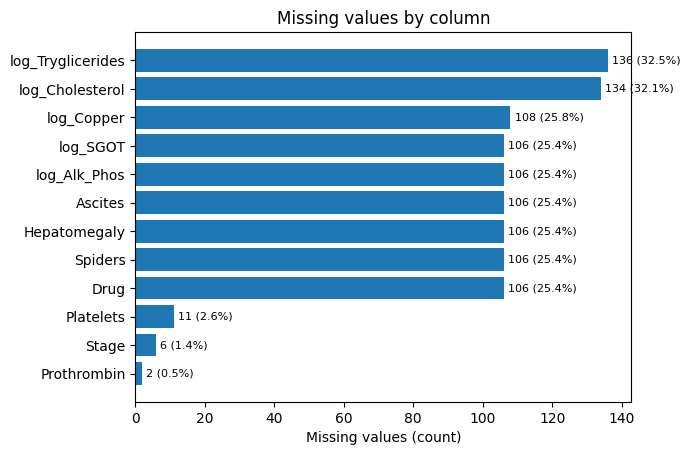


[Missing values]
Columns with missing data (may require imputation):
Prothrombin            2
Stage                  6
Platelets             11
Drug                 106
Spiders              106
Hepatomegaly         106
Ascites              106
log_Alk_Phos         106
log_SGOT             106
log_Copper           108
log_Cholesterol      134
log_Tryglicerides    136

[Numeric distributions]


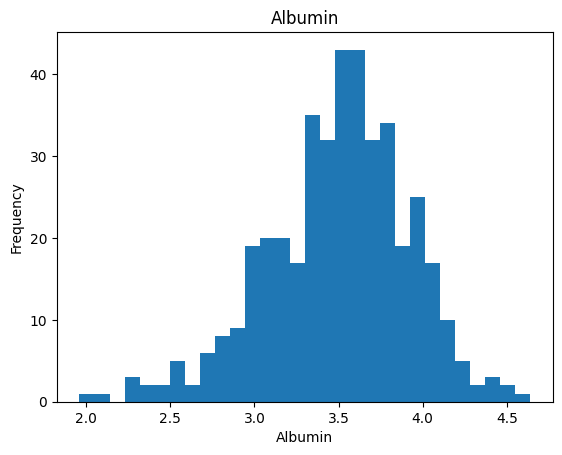

Albumin: shows general shape (skew/spread).


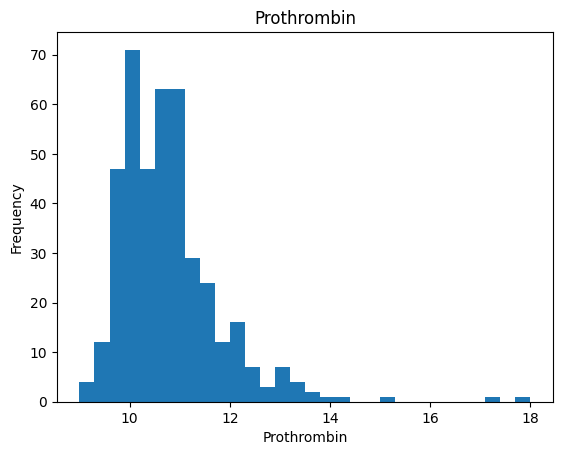

Prothrombin: shows general shape (skew/spread).


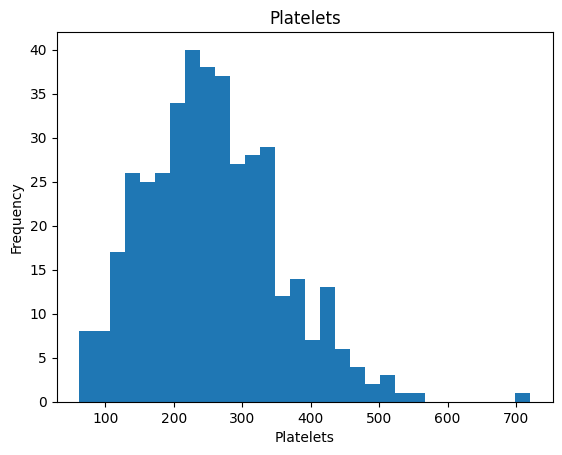

Platelets: shows general shape (skew/spread).


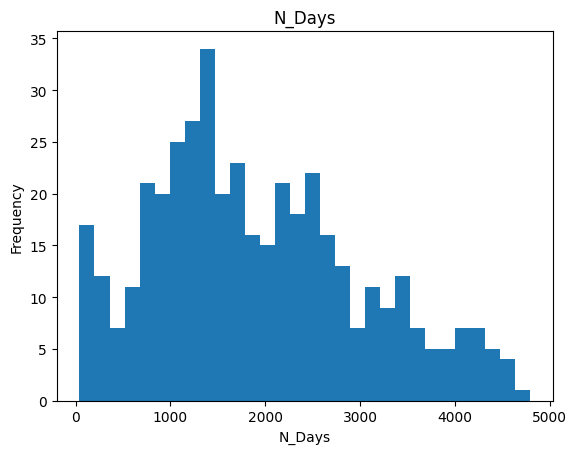

N_Days: shows general shape (skew/spread).


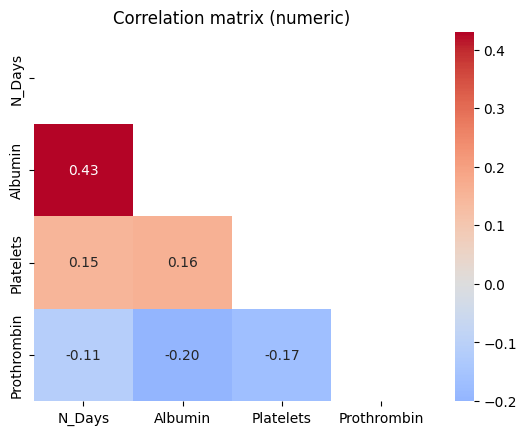


[Correlation]
Values close to 1/-1 indicate strong relation; close to 0 indicate weak relation.


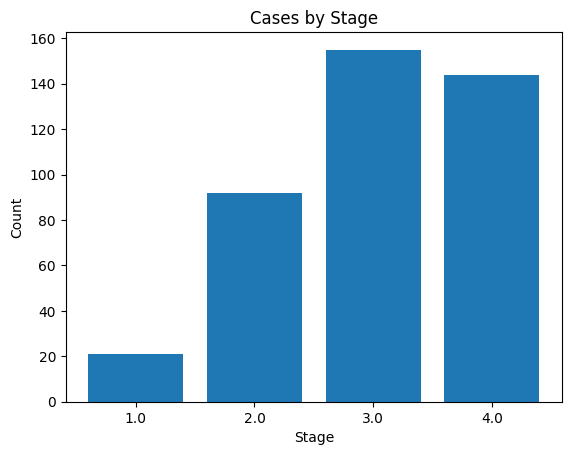


[Stage] Count per stage shown above.


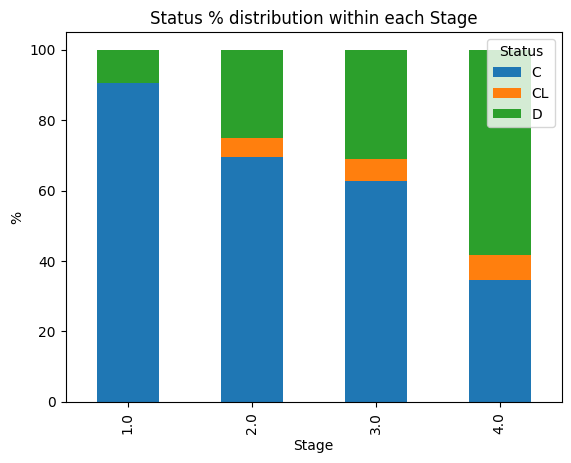

Status percentage within each Stage shown above.
Quick summary
Status counts:
Status
C     232
D     161
CL     25
Missing (if any):
Prothrombin            2
Stage                  6
Platelets             11
Drug                 106
Spiders              106
Hepatomegaly         106
Ascites              106
log_Alk_Phos         106
log_SGOT             106
log_Copper           108
log_Cholesterol      134
log_Tryglicerides    136
Numeric description (selected columns):
        N_Days  Albumin  Platelets  Prothrombin
count   418.00   418.00     407.00       416.00
mean   1917.78     3.50     257.02        10.73
std    1104.67     0.42      98.33         1.02
min      41.00     1.96      62.00         9.00
25%    1092.75     3.24     188.50        10.00
50%    1730.00     3.53     251.00        10.60
75%    2613.50     3.77     318.00        11.10
max    4795.00     4.64     721.00        18.00


In [97]:
print(cirrhosis.shape)
print(cirrhosis.columns.tolist())
plt.style.use("default")

# Status plot
# Simple count

status_counts = cirrhosis["Status"].value_counts()
status_counts.plot(kind="bar")
plt.title("Count by Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

print("Status")
print("Status patient distribution")

# Missing values
# Show missing columns and horizontal bar
missing = cirrhosis.isna().sum()
missing = missing[missing > 0].sort_values(ascending=True)

if len(missing) > 0:
    barras = plt.barh(missing.index, missing.values)
    plt.xlabel("Missing values (count)")
    plt.title("Missing values by column")

    # Genera la lista de textos con las cantidades y porcentajes
    etiquetas = [f"{v} ({(v / len(cirrhosis)) * 100:.1f}%)" for v in missing.values]

    # Aplica las etiquetas directamente al objeto de las barras
    plt.bar_label(barras, labels=etiquetas, padding=3, fontsize=8)

    plt.show()

print("\n[Missing values]")
if len(missing) > 0:
    print("Columns with missing data (may require imputation):")
    print(missing.to_string())
else:
    print("No missing values found.")

#Numeric distributions
# Simple histograms one by one to inspect shape and possible outliers.
numeric_features = ["Age_years", "Bilirubin", "Albumin", "Prothrombin", "Platelets", "N_Days"]

print("\n[Numeric distributions]")
for col in numeric_features:
    if col in cirrhosis.columns:
        plt.hist(cirrhosis[col].dropna(), bins=30)
        plt.title(col)
        plt.xlabel(col)

        plt.ylabel("Frequency")
        plt.show()
        # Short interpretation per column
        print(f"{col}: shows general shape (skew/spread).")

#Correlation
#  heatmap to show linear relationships.
numeric_cols = [
    "Age_years", "N_Days", "Bilirubin", "Cholesterol", "Albumin",
    "Copper", "Alk_Phos", "SGOT", "Tryglicerides", "Platelets", "Prothrombin"
]
# Filter  columns
numeric_cols = [c for c in numeric_cols if c in cirrhosis.columns]

if len(numeric_cols) > 0:
    corr_matrix = cirrhosis[numeric_cols].corr()

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation matrix (numeric)")
    plt.show()

    print("\n[Correlation]")
    print("Values close to 1/-1 indicate strong relation; close to 0 indicate weak relation.")

#  Stage vs Status
# Two simple plots: count by Stage and percentage Status by Stage.
if "Stage" in cirrhosis.columns:
    stage_counts = cirrhosis["Stage"].value_counts()
    stage_counts= stage_counts.sort_index()
    plt.bar(stage_counts.index.astype(str), stage_counts.values)

    plt.xlabel("Stage")
    plt.ylabel("Count")
    plt.title("Cases by Stage")
    plt.show()
    print("\n[Stage] Count per stage shown above.")

    stage_status = pd.crosstab(cirrhosis["Stage"], cirrhosis["Status"], normalize="index") * 100
    stage_status.plot(kind="bar", stacked=True)

    plt.xlabel("Stage")
    plt.ylabel("%")

    plt.title("Status % distribution within each Stage")

    plt.show()
    print("Status percentage within each Stage shown above.")

# Final summaries
print("Quick summary")
print("Status counts:")
print(status_counts.to_string())
print("Missing (if any):")
print(missing.to_string())
print("Numeric description (selected columns):")
if len(numeric_cols) > 0:
    print(cirrhosis[numeric_cols].describe().round(2).to_string())


# 4) Preprocessing

## 4.1) Log transformation

Log transformation is applied for variables with high skew

In [71]:
cirrhosis = cirrhosis.drop(columns=['ID'])

# Convert 'Age' from days to years
cirrhosis['Age'] = (cirrhosis['Age'] / 365.25).round(2)

SKEWED_COLS = ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides']
for col in SKEWED_COLS:
    cirrhosis[f'log_{col}'] = np.log1p(cirrhosis[col])
cirrhosis = cirrhosis.drop(columns=SKEWED_COLS)

## 4.2) Encode categorical variables

In [72]:
target_column = "Status"
X = cirrhosis.drop(columns=[target_column])
y = cirrhosis[target_column]

cat_cols = X.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

## 4.3) Split train-test

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(334, 19) (334,)
(84, 19) (84,)


## 4.4) Handle missing values
Because we have more than one variable with null values, we will use Multivariate imputation methods. This are the different techniques that we will use, and see which one works better for our datasets:

   - Multivariate Imputation by Chained Equations (MICE): This technique models each feature with missing values as a function of other features and iteratively imputes missing values. It can capture complex relationships and is suitable for both numerical and categorical data but can be computationally intensive.

   - MissForest Imputation: This method uses Random Forest models in an iterative way to impute missing values. For each column with missing data, it trains a model using the other columns as predictors and then fills the missing entries. It works well with mixed data types (numerical and categorical), captures non-linear relationships, and is often more accurate than simple imputation methods. However, it can be computationally expensive on larger datasets.


   - K-Nearest Neighbors (KNN) Imputation: This method imputes missing values based on the values of the nearest neighbors in the feature space. It can capture complex relationships between features but can be computationally expensive for large datasets.

In [74]:
def mic_imputation(train: pd.DataFrame , test : pd.DataFrame):
    imputer_mice = IterativeImputer(random_state=RANDOM_STATE)
    train_mice = pd.DataFrame(
        imputer_mice.fit_transform(train),
        columns=train.columns)
    test_mice = pd.DataFrame(
        imputer_mice.transform(test),
        columns= test.columns)
    return train_mice , test_mice

def forest_mic_imputation(train: pd.DataFrame , test : pd.DataFrame):
    imputer_forest = MissForest()
    train_mic_forest = pd.DataFrame(
        imputer_forest.fit_transform(train),
        columns=train.columns)
    test_mic_forest = pd.DataFrame(
        imputer_forest.transform(test),
        columns= test.columns)
    return train_mic_forest , test_mic_forest


def knn_imputation(train: pd.DataFrame , test : pd.DataFrame):
    imputer_knn = KNNImputer()
    train_knn = pd.DataFrame(
        imputer_knn.fit_transform(train),
        columns=train.columns)
    test_knn = pd.DataFrame(
        imputer_knn.transform(test),
        columns= test.columns)
    return train_knn , test_knn


In [75]:
imputation_strategies = {
    "MICE": mic_imputation,
    "MissForest": forest_mic_imputation,
    "KNN": knn_imputation,
}

def evaluate_imputation(X_train, y_train, X_test, y_test, strategies):
    results = []
    for name, imputer_fn in strategies.items():
        # Imputar SOLO train/test de features (sin tocar y)
        X_tr_imp, X_te_imp = imputer_fn(X_train, X_test)

        # Entrenar modelo
        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
        model.fit(X_tr_imp, y_train)

        # Evaluar
        y_pred = model.predict(X_te_imp)
        results.append({
            "strategy": name,
            "f1_score":f1_score(y_test, y_pred , average="macro"),
        })

    return pd.DataFrame(results)

In [76]:
imputation_results_df = evaluate_imputation(
    X_train, y_train, X_test, y_test, imputation_strategies
)
imputation_results_df

100%|██████████| 3/3 [00:00<00:00, 61.22it/s]


,strategy,f1_score
0,MICE,0.536511
1,MissForest,0.525876
2,KNN,0.525876


### 4.4.1 Choosing best imputation technique
Based on the results of our imputation strategies, we will select the one that yields the best performance on our evaluation metrics. This will be the imputation method we will use for the next steps in our analysis. We will also analyze the impact of the chosen imputation method on the distribution of our features and the target variable to ensure that it does not introduce bias or distort the data in a way that could affect our model's performance.

In [77]:
best_imputation_strategy = imputation_results_df.sort_values(by="f1_score", ascending=False)["strategy"][0]
print(f"Best imputation strategy: {best_imputation_strategy}")

imputation_funct = imputation_strategies[best_imputation_strategy]

X_train, X_test = imputation_funct(X_train, X_test)

Best imputation strategy: MICE


## 4.5) Under sampling and over sampling
In this step we will apply under sampling and over sampling techniques to handle the class imbalance in our dataset. Under sampling involves reducing the number of samples in the majority class, while over sampling involves increasing the number of samples in the minority class. We will compare the performance of our models using these techniques to see which one works better for our dataset.

In [78]:
sampling_strategies = {
    "baseline": None, # No sampling (comparison)
    "ENN (Under-sampling)": EditedNearestNeighbours(),
    "SMOTE (Over-sampling)": SMOTE(random_state=RANDOM_STATE),
    "SMOTEENN (Combined)": SMOTEENN(random_state=RANDOM_STATE),
}

def evaluate_sampling(X_train, y_train, X_test, y_test, strategies):
    results = []

    for name, sampler in strategies.items():
        # Apply sampling to training data only
        if sampler is None:
            X_res, y_res = X_train, y_train
        else:
            X_res, y_res = sampler.fit_resample(X_train, y_train)

        # Train model
        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
        model.fit(X_res, y_res)

        # Evaluate
        y_pred = model.predict(X_test)

        results.append({
            "strategy": name,
            "accuracy": accuracy_score(y_test, y_pred)
        })

    return pd.DataFrame(results)


In [79]:
results_df = evaluate_sampling(X_train, y_train, X_test, y_test, sampling_strategies)

results_df

,strategy,accuracy
0,baseline,0.785714
1,ENN (Under-sampling),0.690476
2,SMOTE (Over-sampling),0.750000
3,SMOTEENN (Combined),0.619048


### 4.5.1 Choosing best sampling strategy
Based on the results of our sampling strategies, we will select the one that yields the best performance on our evaluation metrics. This will be the sampling method we will use for the next steps in our analysis. We will also analyze the impact of the chosen sampling method on the distribution of our features and the target variable to ensure that it does not introduce bias or distort the data in a way that could affect our model's performance. Additionally, we will consider the computational cost and complexity of the sampling method, as some techniques may be more resource-intensive than others, especially when dealing with large datasets. Ultimately, our goal is to find a sampling strategy that effectively addresses the class imbalance while maintaining or improving the overall performance of our classification model.

In [80]:
best_sampling_strategy = results_df.sort_values(by="accuracy", ascending=False)["strategy"][0]
print(f"Best sampling strategy: {best_sampling_strategy}")

sampling_func = sampling_strategies[best_sampling_strategy]

if sampling_func is not None:
    X_train, y_train= sampling_func.fit_resample(X_train, y_train)

Best sampling strategy: baseline


## 4.6) Multi-class classification

In this step we compare multiclass strategies depending on whether the base model outputs probabilities or not.

In [81]:
multiclass_models = {
    # Probabilistic output: direct softmax is usually the most efficient for logistic regression.
    "Softmax": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
        multi_class="multinomial",
        ),

    # No probability output: independent binary classifiers for each class (One-vs-Rest) or pair of classes (One-vs-One).
    "One-vs-Rest": OneVsRestClassifier(
        LinearSVC(random_state=RANDOM_STATE)
    ),
    "One-vs-One": OneVsOneClassifier(
        LinearSVC(random_state=RANDOM_STATE)
    ),
}

def evaluate_multiclass_strategies(models, X_train, y_train, X_test, y_test):
    rows = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rows.append(
            {
                "strategy": name,
                "accuracy": accuracy_score(y_test, y_pred)
            }
        )
    return pd.DataFrame(rows)


In [82]:
multiclass_results_df = evaluate_multiclass_strategies(
    multiclass_models,
    X_train,
    y_train,
    X_test,
    y_test,
)

multiclass_results_df

,strategy,accuracy
0,Softmax,0.738095
1,One-vs-Rest,0.726190
2,One-vs-One,0.726190


# 5) Explainability

In [83]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Train model
model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
model.fit(X_train, y_train_enc)

class_names = le.classes_

print(classification_report(y_test_enc, model.predict(X_test), target_names=class_names))


              precision    recall  f1-score   support

           C       0.79      0.87      0.83        47
          CL       0.00      0.00      0.00         5
           D       0.78      0.78      0.78        32

    accuracy                           0.79        84
   macro avg       0.52      0.55      0.54        84
weighted avg       0.74      0.79      0.76        84


## 5.1) Explainability with SHAP

1. Train a Random Forest on the cirrhosis dataset.
2. Use SHAP to compute feature contributions for each prediction.
3. Display a summary plot showing which features most influence predictions.

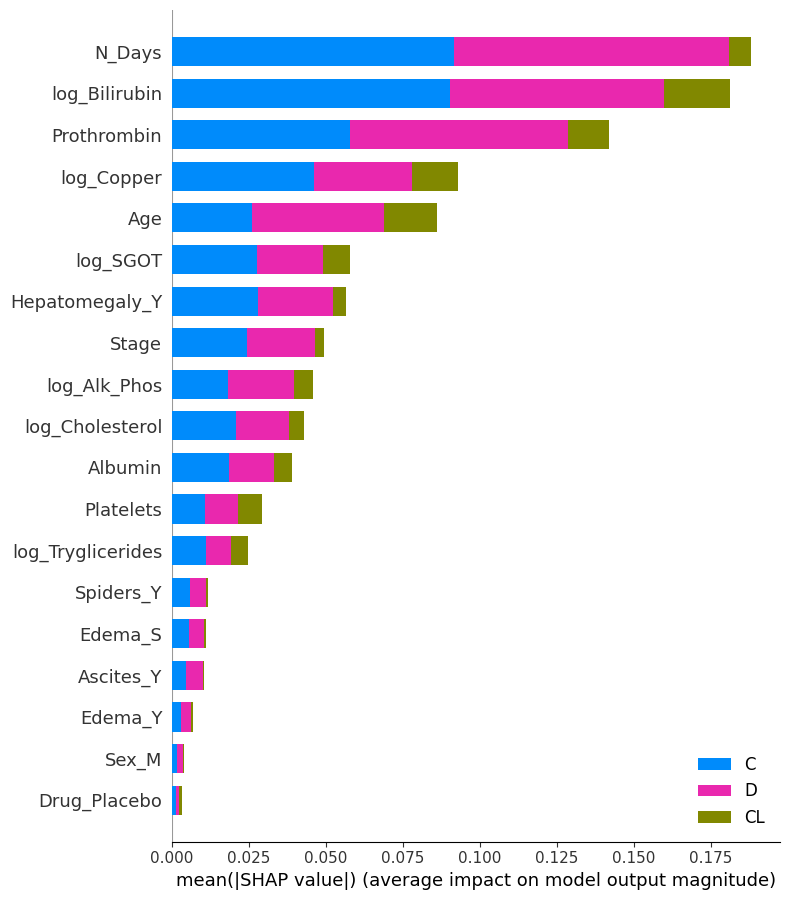

Class: C


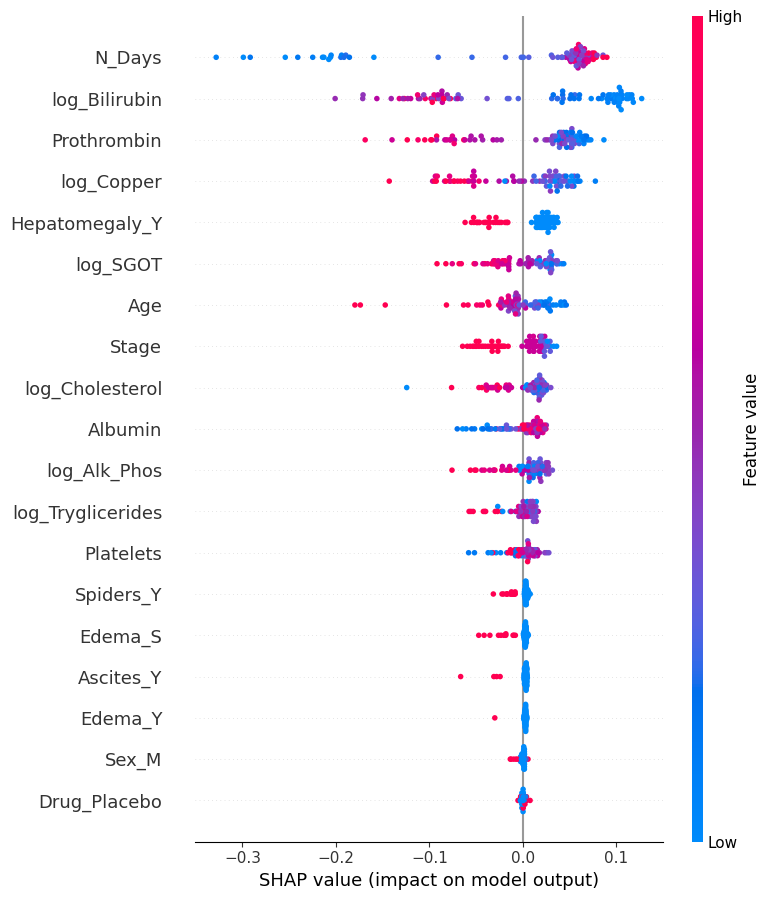

Class: CL


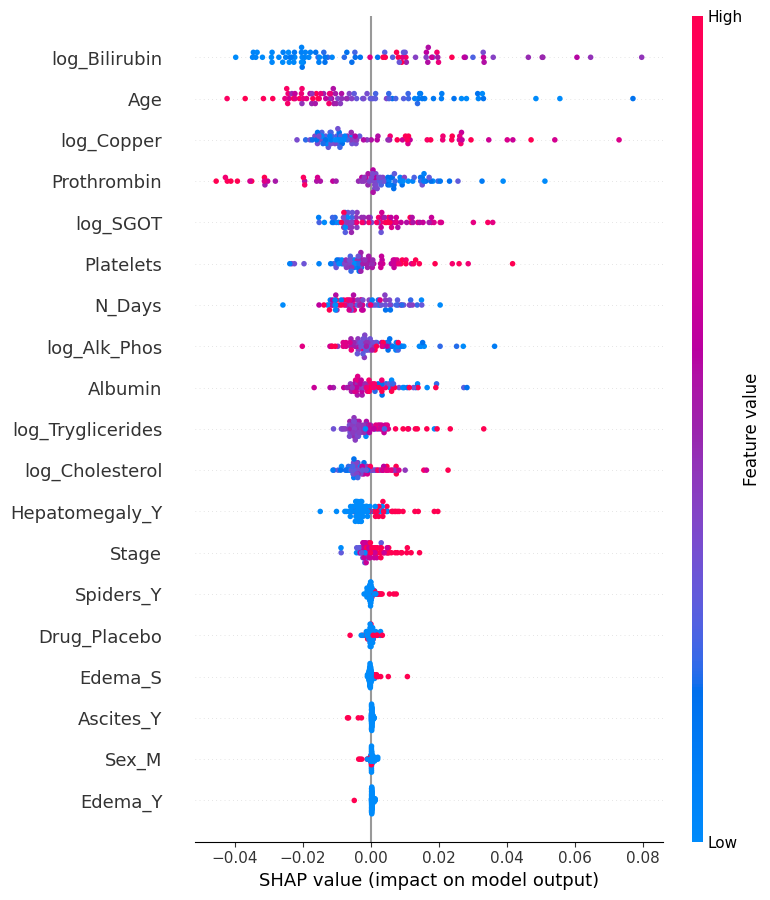

Class: D


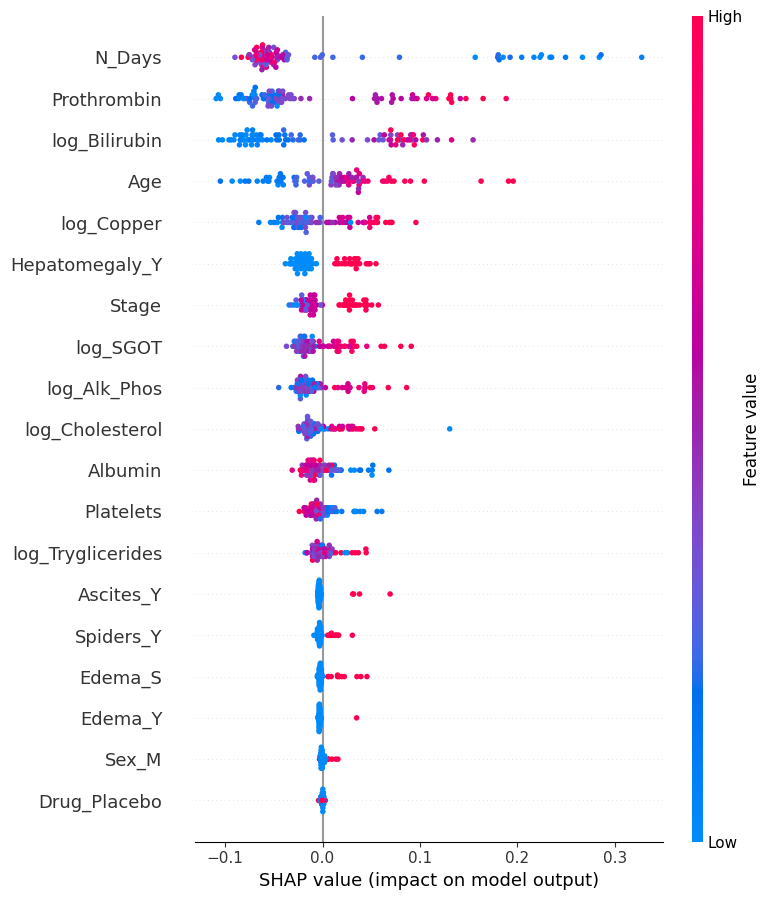

In [84]:
# Create SHAP explainer and compute SHAP values
explainer = shap.TreeExplainer(model)
sv_raw = explainer.shap_values(X_test) # (n_samples, n_features, n_classes)
shap_values = [sv_raw[:, :, i] for i in range(len(class_names))]

# Global importance
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist(),
                  class_names=class_names, plot_type='bar')

# Beeswarm per class
for i, cls in enumerate(class_names):
    print(f"Class: {cls}")
    shap.summary_plot(shap_values[i], X_test, feature_names=X_test.columns.tolist())

## 5.2) Local Explainability (SHAP Waterfall)

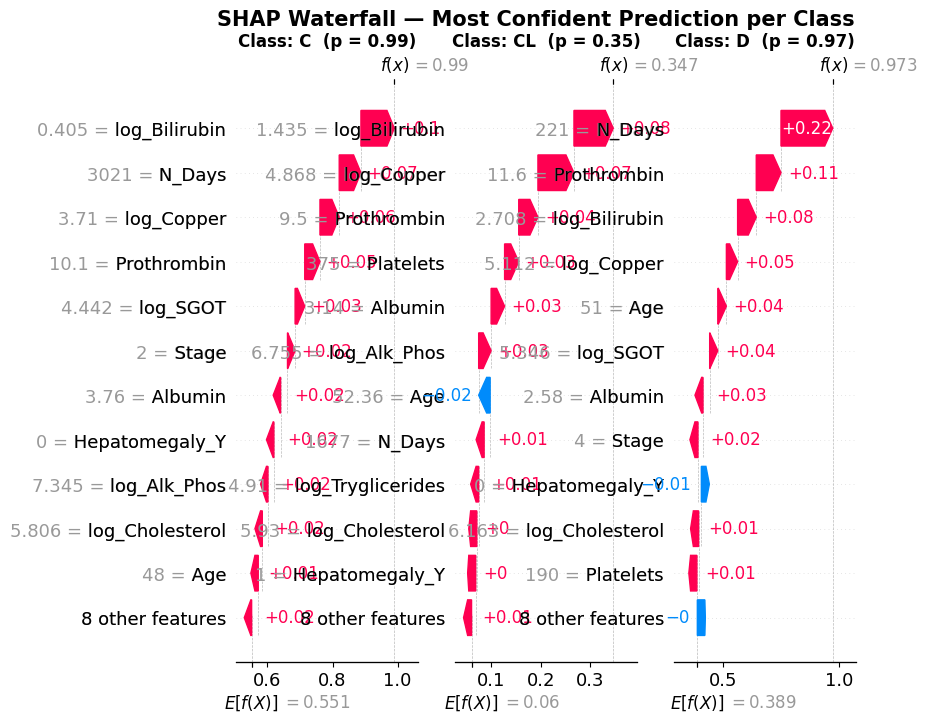

In [85]:
proba_test = model.predict_proba(X_test)
rep_idx = [np.argmax(proba_test[:, i]) for i in range(len(class_names))]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('SHAP Waterfall — Most Confident Prediction per Class', fontsize=15, fontweight='bold')

for i, (cls, idx) in enumerate(zip(class_names, rep_idx)):
    plt.sca(axes[i])
    sv = shap.Explanation(
        values = shap_values[i][idx],
        base_values = explainer.expected_value[i],
        data = X_test.iloc[idx].values,
        feature_names = X_test.columns.tolist()
    )
    shap.waterfall_plot(sv, max_display=12, show=False)
    axes[i].set_title(f'Class: {cls}  (p = {proba_test[idx, i]:.2f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5.3) PDP (Partial Dependence Plots)

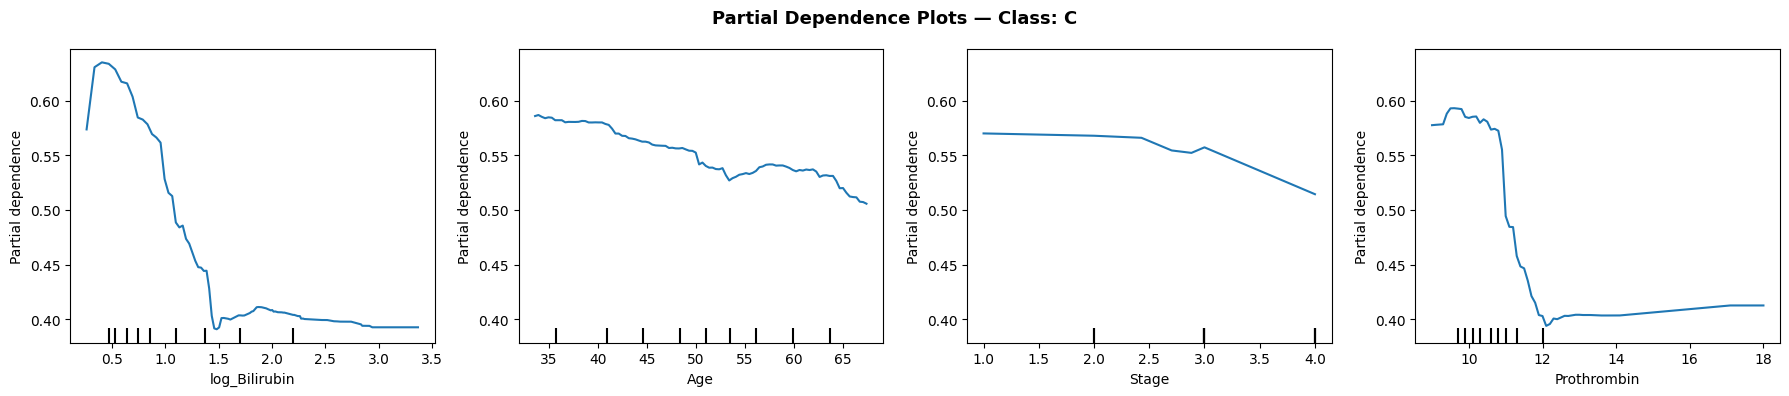

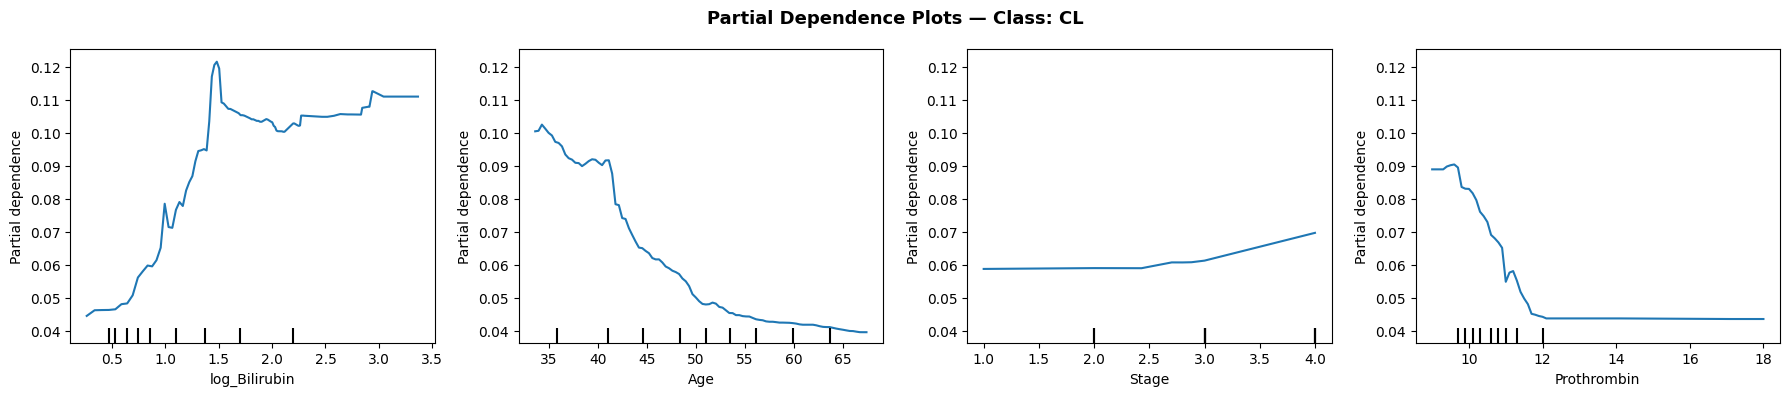

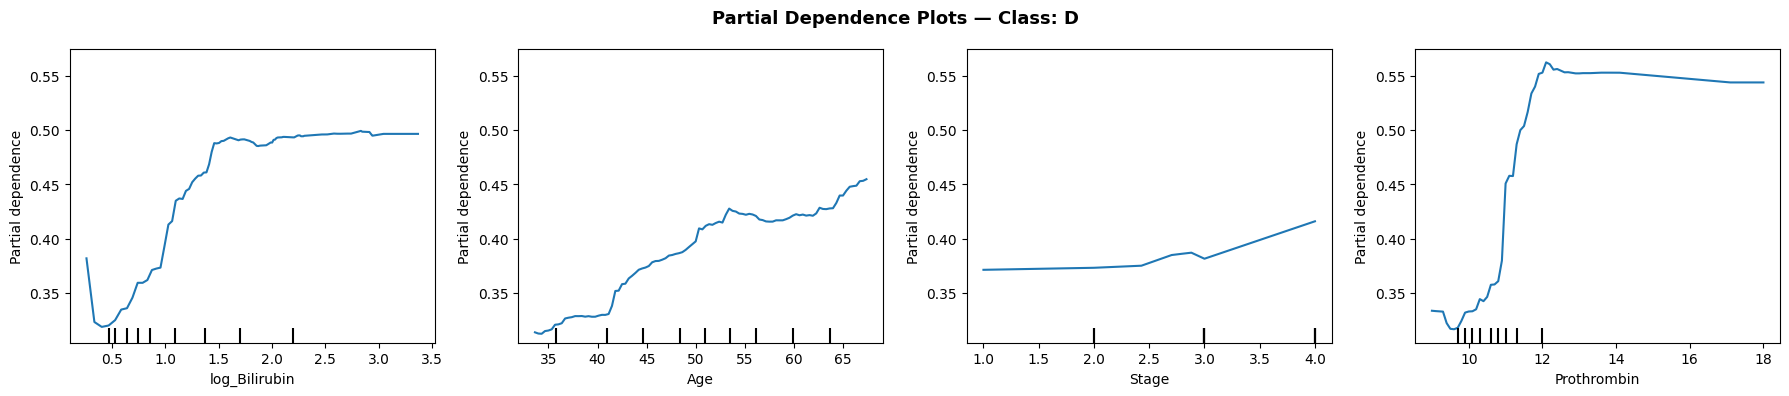

In [95]:
TOP_FEATURES = ['log_Bilirubin', 'Age', 'Stage', 'Prothrombin']

for i, cls in enumerate(class_names):
    fig, ax = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Partial Dependence Plots — Class: {cls}', fontsize=13, fontweight='bold')

    PartialDependenceDisplay.from_estimator(
        model, X_train,
        features=TOP_FEATURES,
        target=i,
        ax=ax
    )
    plt.tight_layout()
    plt.show()

## 5.4) ALE (Accumulated Local Effects)

PyALE._ALE_generic:INFO: Continuous feature detected.


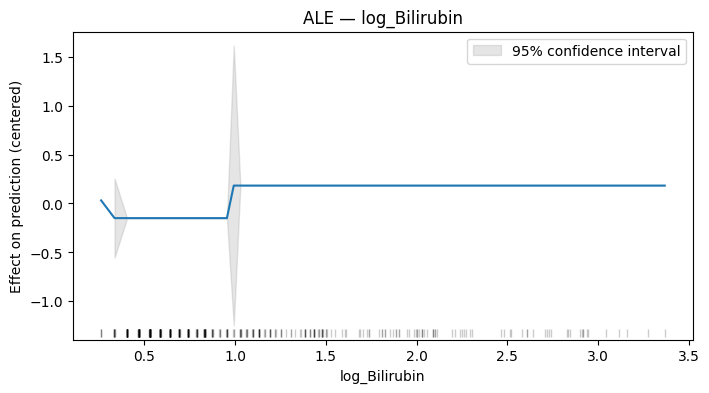

PyALE._ALE_generic:INFO: Continuous feature detected.


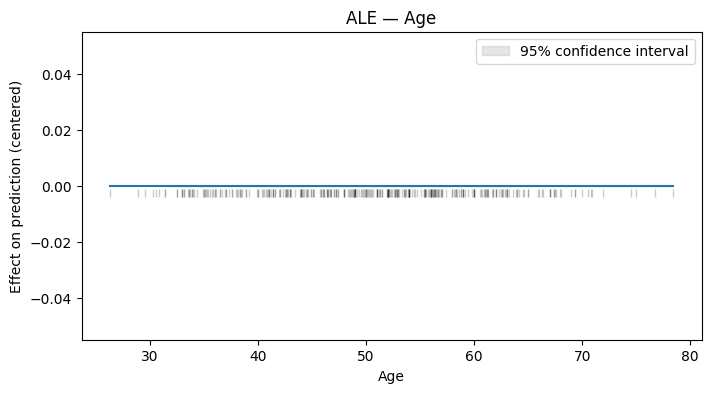

PyALE._ALE_generic:INFO: Discrete feature detected.


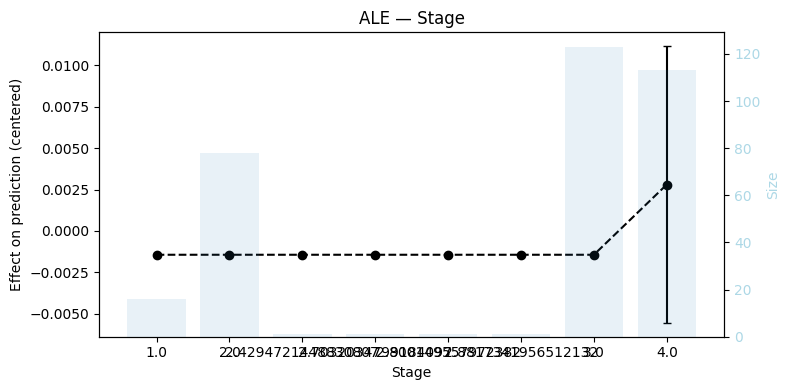

PyALE._ALE_generic:INFO: Continuous feature detected.


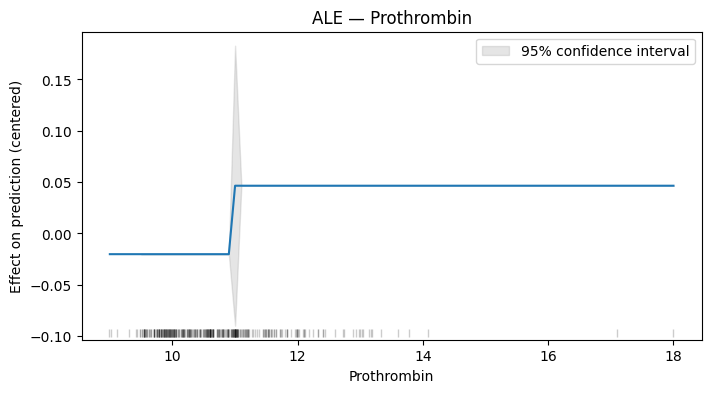

In [87]:
TOP_FEATURES = ['log_Bilirubin', 'Age', 'Stage', 'Prothrombin']
top_idx = [X_train.columns.tolist().index(f) for f in TOP_FEATURES]

for feat in TOP_FEATURES:
    ale_eff = ale(X=X_train, model=model, feature=[feat], grid_size=50, plot=True)
    plt.title(f'ALE — {feat}')
    plt.show()

## 5.5) Explainability with LIME

In [88]:
def plot_lime_explanation(exp, class_idx, class_name, predict_proba, instance, num_features=10):
    '''Plots a LIME explanation for a given instance and class.
    Parameters:
    - exp: LIME explanation object
    - class_idx: index of the class being explained
    - class_name: name of the class being explained
    - predict_proba: function to get prediction probabilities from the model
    - instance: the data instance being explained (1D array)
    - num_features: number of top features to display
    '''
    exp_list = sorted(exp.as_list(label=class_idx), key=lambda x: x[1])
    feats = [e[0] for e in exp_list]
    weights = [e[1] for e in exp_list]
    colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]

    probas = predict_proba([instance])[0]

    fig, (ax_bar, ax_prob) = plt.subplots(1, 2, figsize=(14, 5),
                                           gridspec_kw={'width_ratios': [3, 1]})
    fig.suptitle(f'LIME Explanation — Class: {class_name}', fontsize=14, fontweight='bold')

    # Left panel: horizontal bars with the weights of each feature
    bars = ax_bar.barh(feats, weights, color=colors, edgecolor='white', linewidth=0.5)

    # Vertical line in x=0 to separate from positive and negative contributions
    ax_bar.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    ax_bar.set_xlabel('Feature weight', fontsize=11)
    ax_bar.set_title('Feature contributions', fontsize=12)
    ax_bar.spines[['top', 'right']].set_visible(False)
    for bar, w in zip(bars, weights):
        ax_bar.text(w + 0.001 if w >= 0 else w - 0.001, bar.get_y() + bar.get_height()/2,
                    f'{w:.3f}', va='center', ha='left' if w >= 0 else 'right', fontsize=8)

    # Right panel: predicted probabilities for each class
    bar_colors = ['#2ecc71' if i == class_idx else '#aab4be' for i in range(len(probas))]
    ax_prob.barh(model.classes_, probas, color=bar_colors, edgecolor='white')
    ax_prob.set_xlim(0, 1)
    ax_prob.set_xlabel('Probability', fontsize=11)
    ax_prob.set_title('Prediction probabilities', fontsize=12)
    ax_prob.spines[['top', 'right']].set_visible(False)

    # Add the numerical value of the weight next to each bar
    for i, p in enumerate(probas):
        ax_prob.text(p + 0.01, i, f'{p:.2f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

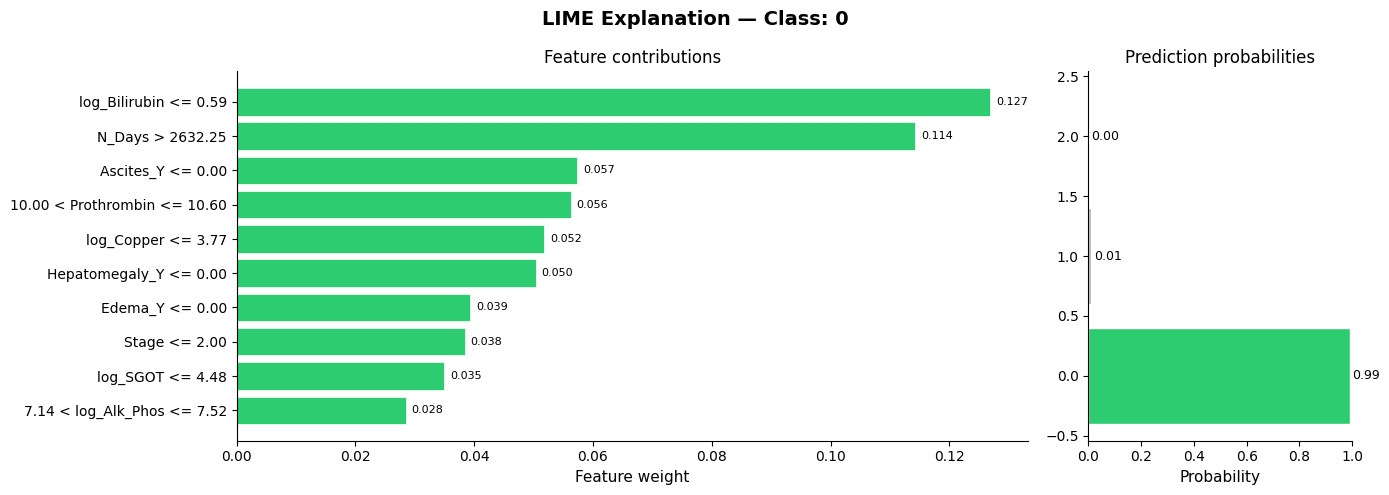

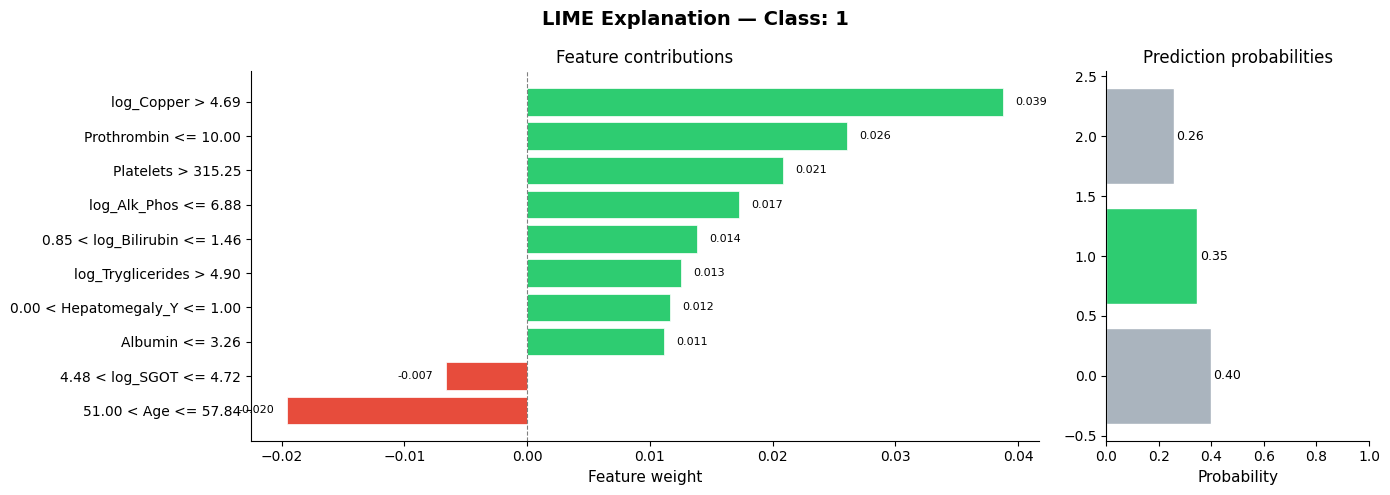

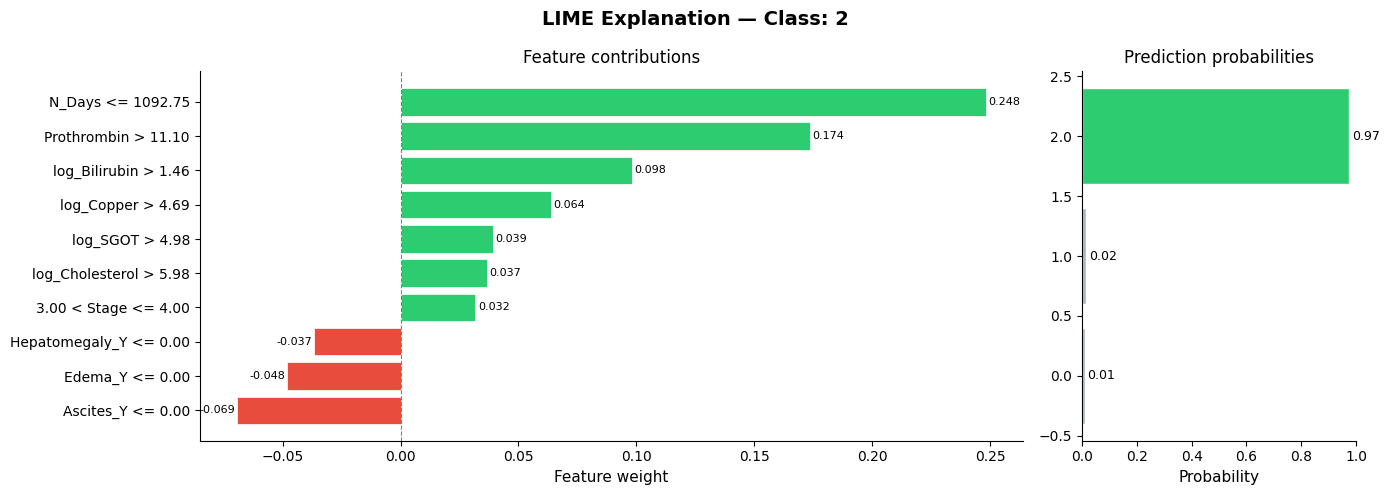

In [89]:
lime_exp = LimeTabularExplainer(
    X_train.values, feature_names=X_train.columns.tolist(),
    class_names=model.classes_, mode='classification', random_state=RANDOM_STATE
)

proba_test = model.predict_proba(X_test)

# For each class, find the instance with the highest predicted probability and plot its LIME explanation
for i, cls in enumerate(model.classes_):
    idx = np.argmax(proba_test[:, i])
    exp = lime_exp.explain_instance(X_test.iloc[idx].values, model.predict_proba,
                                    num_features=10, labels=[i])
    plot_lime_explanation(exp, i, cls, model.predict_proba, X_test.iloc[idx].values)
    # exp.show_in_notebook(show_table=True)

## 5.6) Counterfactual (DiCE)

In [90]:
train_df = X_train.copy()
train_df['Status'] = y_train_enc

# Define the data object of DiCE
d = dice_ml.Data(
    dataframe=train_df,
    continuous_features=X_train.columns.tolist(),
    outcome_name='Status'
)

# Define the model object of DiCE
m = dice_ml.Model(model=model, backend='sklearn')

# Create the explainer
exp = dice_ml.Dice(d, m, method='random')

In [ ]:
# Generate counterfactuals for a deceased patient (class D = 2)
# We look for a patient that the model predicts as D with high confidence
proba_test = model.predict_proba(X_test)
idx_deceased = np.argmax(proba_test[:, 2]) # Patient more confident in class D

query_instance = X_test.iloc[[idx_deceased]]

# Ask for 3 counterfactuals: what would have to change for it NOT to be class D
cf = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class=0,  # 0=C (alive) — what would have to change for it to survive
    permitted_range={
        'log_Bilirubin': [X_train['log_Bilirubin'].min(), X_train['log_Bilirubin'].max()],
        'Stage': [1, 4],
        'Prothrombin': [X_train['Prothrombin'].min(), X_train['Prothrombin'].max()],
    }
)

cf.visualize_as_dataframe(show_only_changes=True)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.30it/s]

Query instance (original outcome : 2)


,N_Days,Age,Albumin,Platelets,Prothrombin,Stage,log_Bilirubin,log_Cholesterol,log_Copper,log_Alk_Phos,log_SGOT,log_Tryglicerides,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y,Status
0,221.0,51.0,2.58,190.0,11.6,4.0,2.70805,6.162549,5.112163,7.468386,5.346273,4.936853,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2



Diverse Counterfactual set (new outcome: 0)


,N_Days,Age,Albumin,Platelets,Prothrombin,Stage,log_Bilirubin,log_Cholesterol,log_Copper,log_Alk_Phos,log_SGOT,log_Tryglicerides,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y,Status
0,2514.5,-,3.49,68.5,10.2,-,-,-,-,-,4.373087,-,-,-,-,-,-,-,-,0.0
1,3738.6,-,-,-,10.4,-,-,-,4.8167106,-,4.646695,-,-,0.9,2.7755575615628914e-17,-,-,-,2.7755575615628914e-17,0.0
2,2515.5,-,-,272.5,10.2,-,1.36667362,-,-,-,4.627039,-,-,-,2.7755575615628914e-17,-,-,-,-,0.0


## 5.7) Intrinsic Explainability

              precision    recall  f1-score   support

           C       0.72      0.72      0.72        47
          CL       0.06      0.20      0.09         5
           D       0.68      0.41      0.51        32

    accuracy                           0.57        84
   macro avg       0.49      0.44      0.44        84
weighted avg       0.67      0.57      0.60        84


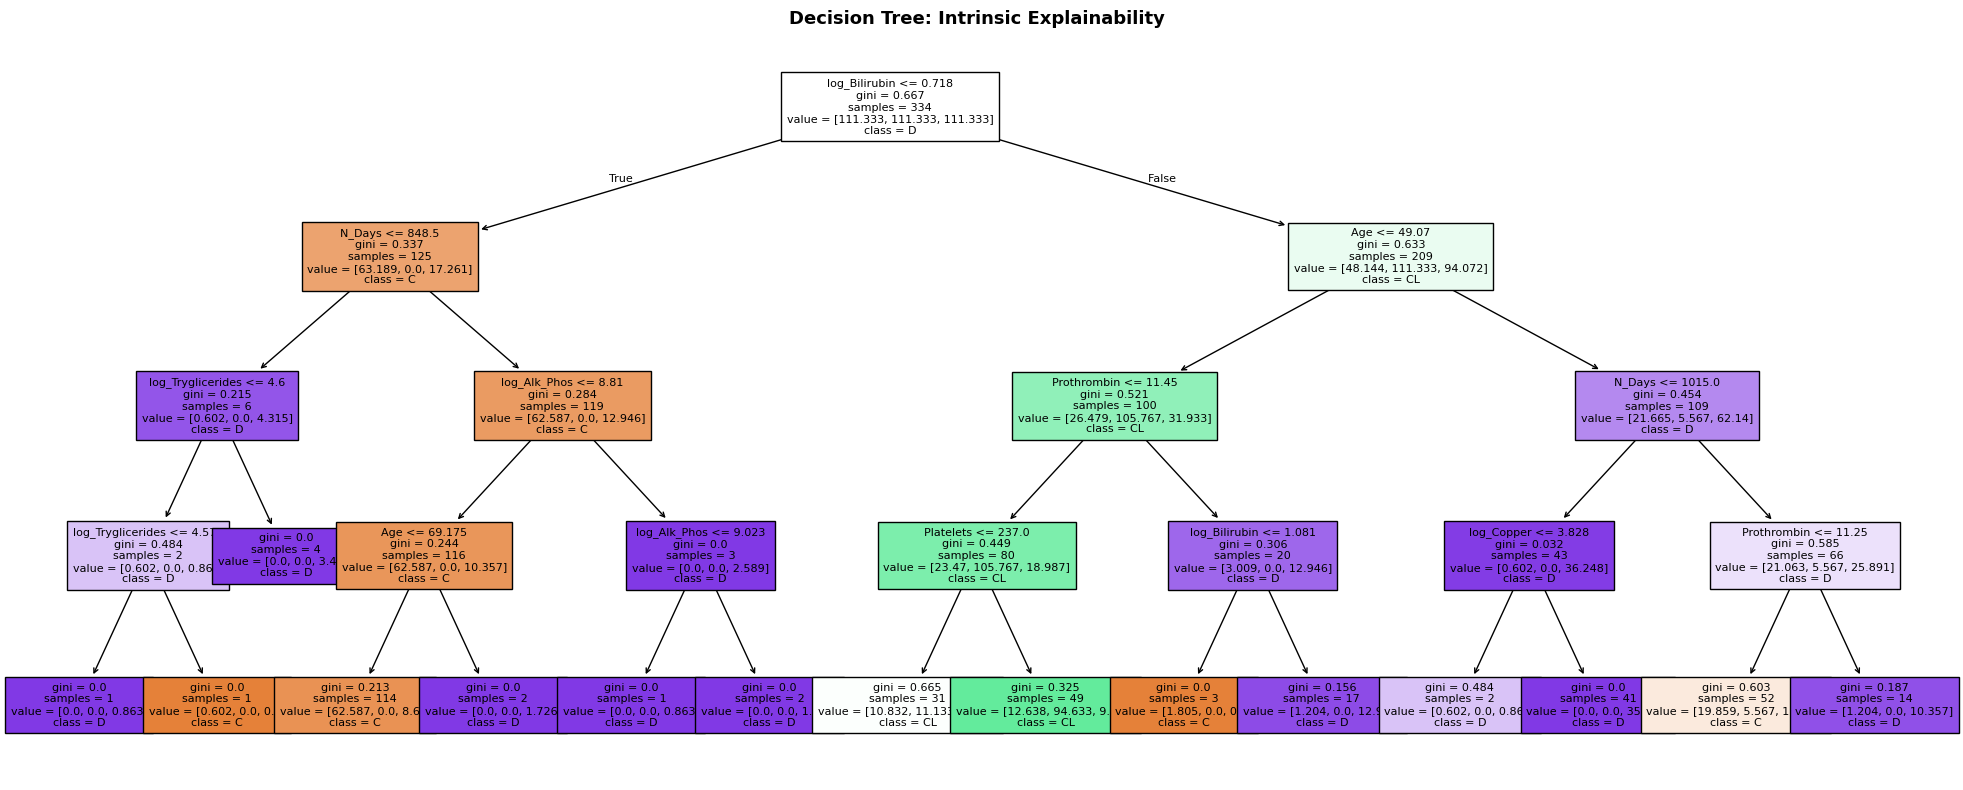

In [96]:
dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=RANDOM_STATE)
dt.fit(X_train, y_train_enc)

print(classification_report(y_test_enc, dt.predict(X_test), target_names=class_names))

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=X_train.columns.tolist(),
          class_names=class_names, filled=True, fontsize=8, ax=ax)
plt.title('Decision Tree: Intrinsic Explainability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.7.1 Importance of features

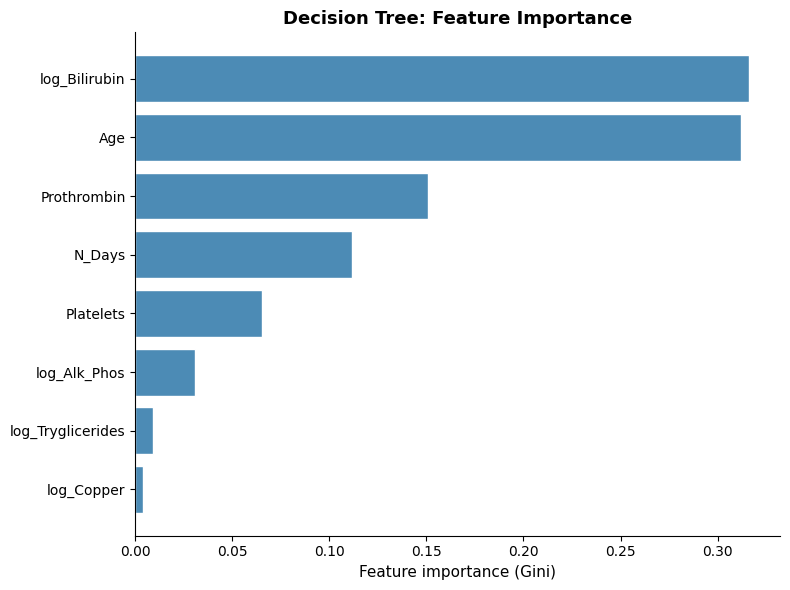

In [ ]:
# Importance of features of the Decision Tree
importances = dt.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([X_train.columns[i] for i in sorted_idx if importances[i] > 0],
        [importances[i] for i in sorted_idx if importances[i] > 0],
        color='#4c8bb5', edgecolor='white')
ax.set_xlabel('Feature importance (Gini)', fontsize=11)
ax.set_title('Decision Tree: Feature Importance', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# 6) Conclusions

## Data and Preprocessing
The cirrhosis dataset presented three challenges that required explicit treatment: structural missingness in 106 non-trial patients, class imbalance in the target variable (CL = 6%), and right-skewed laboratory values. Among the three imputation strategies evaluated, MICE achieved the highest F1 score (0.537), marginally outperforming MissForest and KNN (both 0.526). However, the differences are small, suggesting that the structural missingness pattern, rather than the imputation method itself, is the dominant factor limiting model performance on this dataset. MICE was selected as the best strategy and applied to the final train and test sets.

## Class Imbalance
The baseline (no sampling) achieved the highest accuracy (0.809), outperforming SMOTE, ENN and SMOTEENN. This result is misleading: as the Random Forest classification report confirms, the model completely ignores the CL class (F1 = 0.00), and high accuracy is driven by the majority class C (55.5%). This illustrates why accuracy is not a suitable metric for imbalanced multi-class problems, and macro-averaged F1 is the more informative measure.

## Model Performance
The Random Forest (macro F1 = 0.55) outperformed the Decision Tree (macro F1 = 0.49) across all classes. Among the multiclass strategies, Softmax achieved the highest accuracy (0.738), slightly ahead of One-vs-Rest and One-vs-One (both 0.726). Both models struggled with the CL class due to its extremely small size (25 patients, 5 in test set). The Random Forest achieved strong performance on C (F1 = 0.87) and acceptable performance on D (F1 = 0.78), which are the two clinically most critical classes.

## Explainability Findings
All XAI methods converged on the same set of top features: log_Bilirubin, Prothrombin, Stage, and Albumin. This consistency across SHAP, LIME, PDP, ALE and the Decision Tree splits provides strong evidence that the model has learned clinically meaningful patterns, as these features are exactly the components of the MELD and Child-Pugh scores used in clinical practice to assess PBC severity.

The SHAP waterfall plots revealed that individual predictions are dominated by log_Bilirubin and Prothrombin, with their direction of effect being medically coherent: high bilirubin and prolonged prothrombin time both increase the predicted probability of death. The DiCE counterfactuals confirmed this, showing that normalising bilirubin levels would be sufficient to shift the model's prediction from D to C in the most confident deceased patient.

## Limitations
- The CL class (liver transplant) is essentially unpredictable with this dataset   size. Merging CL with C would be justified in a production setting.
- N_Days (follow-up duration) appeared as an important feature in several explainability methods, but it is not a clinically actionable variable and introduces a form of data leakage — patients who died early necessarily have low N_Days. It should be excluded in future iterations.
- All XAI methods show correlation, not causation. The fact that high bilirubin is associated with mortality does not mean that reducing bilirubin will improve survival — that is a clinical question that requires a controlled trial.
- LIME explanations are locally linear approximations and can be unstable across repeated runs, making them less reliable than SHAP for this dataset.